In [1]:
%load_ext autoreload

In [2]:
import os
from unity_utils import UnityTranslator

dir = os.getcwd()
DATA_DIR = dir + '/data/give-and-go'
demos = UnityTranslator.get_from(DATA_DIR, sample_rate=1)

Stored 23 frames.
Stored 20 frames.
Stored 14 frames.


In [3]:
from scenic_fc.api import api
from infer_utils import Inference
acts = Inference.act_from(demos[0], api)

100%|██████████| 1/1 [00:22<00:00, 22.93s/it]


In [5]:
acts[0].id

'demo_0'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Editing done.


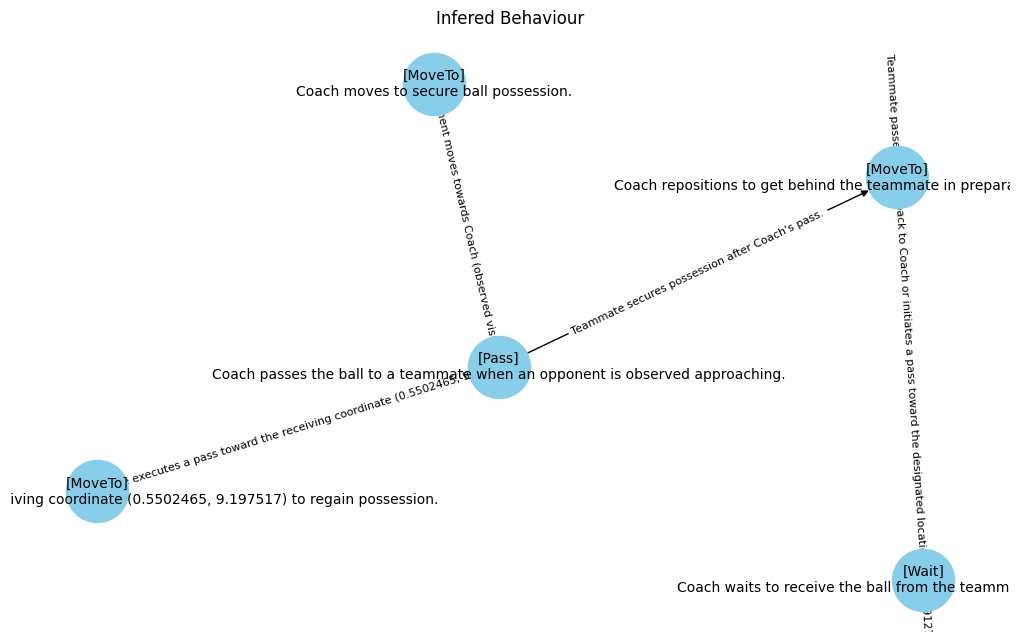

In [4]:
%load_ext autoreload
%autoreload 2

combined = Inference.combine(acts=acts, api=api)
combined.show()

In [5]:
[a.id for a in acts]

['demo_0', 'demo_1', 'demo_2']

In [6]:
combined.to_dict(expanded=False)

{'outline': 'This final FSM combines the sub-behaviours observed in the demonstrations. The coach begins by ensuring ball possession. When an opponent approaches, the coach passes the ball to a teammate. After the pass, two branches are possible depending on the observed teammate action. In one branch (derived from demo_1 and demo_2), after the teammate secures the ball the coach repositions behind the teammate and then waits to receive a return pass – in one case the return pass is initiated toward a designated location (3.33099127, 9.400471). In the alternative branch (from demo_0), immediately after the pass the coach moves directly to a designated receiving coordinate (0.5502465, 9.197517) to regain possession. Both branches complete the move and go behavior by ending in regained ball possession.',
 'nodes': [{'target': {'info': 'Coach moves to secure ball possession.',
    'logic': None,
    'map': [],
    'constraints': [],
    'reasoning': ''},
   'id': '0',
   'action': 'MoveTo

In [ ]:
combined.to_dict(expanded=False)

In [ ]:
import json

data = combined.to_dict(id='combined_fix', expanded=False)

with open('exports/combined_fix.json', 'w') as f:
    json.dump(data, f, indent=4)

In [ ]:
combined.nodes[0].termination

In [ ]:
import json

OUT_DIR = 'exports'

os.makedirs(OUT_DIR, exist_ok=True)
for idx, a in enumerate(acts):

    id = f'act_{idx + 1}'
    data = a.to_dict(id=id, expanded=False)

    with open(f'{OUT_DIR}/{id}.json', 'w') as f:
        json.dump(data, f, indent=4)

In [ ]:
%load_ext autoreload
%autoreload 2

combined.nodes[1].synth(demos, api)

In [ ]:
%load_ext autoreload
%autoreload 2

from synth_utils import Synth

synth = Synth(combined, demos, api)
synth.run()

In [ ]:
import json    

program = synth.to_dict()
print(json.dumps(program, indent=4))

In [ ]:
%load_ext autoreload
%autoreload 2

demos[0].scene['Coach'][0][20.0].location.x

In [ ]:
for i in demos[0].scene['Coach'][0].location:
    print(i.x)